In [1]:
# install FRED api (Federal Reserve Bank at St Louis)
!pip install fredapi

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from fredapi import Fred
from google.colab import userdata

FRED_API_KEY = userdata.get('MY_FRED')
fred = Fred(api_key=FRED_API_KEY)

# GDP - tényadat (A191RL1Q225SBEA)
Real Gross Domestic Product: Percent Change from Preceding Period

In [2]:
df_all = fred.get_series_all_releases('A191RL1Q225SBEA')

# Negyedéves becslés első megjelenési dátuma
df_all = df_all.sort_values(by=['date', 'realtime_start']) # Sorbarendezés először vonatkozó hónap (date) azon belül publikálás napja (realtime_start) szerint
df_releases= df_all.drop_duplicates(subset='date', keep='first').copy() # Az első publikálás értékét tartjuk meg
display(df_all)

,realtime_start,date,value
0,2014-09-26 00:00:00,1947-04-01 00:00:00,-0.4
1,2018-07-27 00:00:00,1947-04-01 00:00:00,-1.0
2,2021-07-29 00:00:00,1947-04-01 00:00:00,-1.1
3,2023-09-28 00:00:00,1947-04-01 00:00:00,-1.0
4,2014-09-26 00:00:00,1947-07-01 00:00:00,-0.4
...,...,...,...
898,2025-12-23 00:00:00,2025-07-01 00:00:00,4.3
899,2026-01-22 00:00:00,2025-07-01 00:00:00,4.4
900,2026-02-20 00:00:00,2025-10-01 00:00:00,1.4
901,2026-03-13 00:00:00,2025-10-01 00:00:00,0.7


/tmp/ipykernel_13831/283076696.py:23: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_final_signal = df_filtered.groupby('realtime_start')['value'].last().reindex(full_range).ffill()


,gdp_official_point_in_time
2014-09-26,4.6
2014-09-27,4.6
2014-09-28,4.6
2014-09-29,4.6
2014-09-30,4.6
...,...
2026-04-05,0.7
2026-04-06,0.7
2026-04-07,0.7
2026-04-08,0.7


<Figure size 640x480 with 0 Axes>

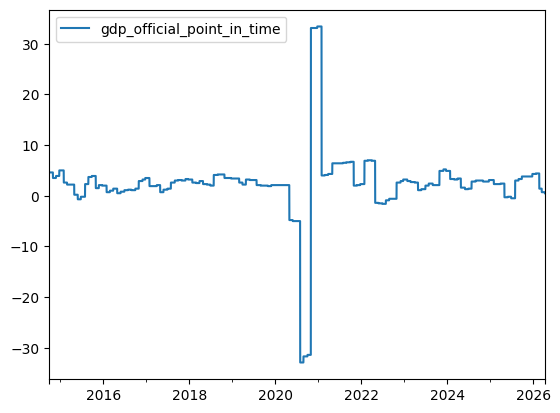

In [3]:
# Adattisztítás
df_all['realtime_start'] = pd.to_datetime(df_all['realtime_start'])
df_all['date'] = pd.to_datetime(df_all['date'])
df_all = df_all.sort_values(['realtime_start', 'date'])

# Az adott negyedévre vonatkozó publikált érték
first_releases = df_all.drop_duplicates(subset='date', keep='first').copy()

# Megadja, hogy melyik a legfrissebb negyedév
latest_quarter_series = first_releases.groupby('realtime_start')['date'].last()
full_range = pd.date_range(df_all['realtime_start'].min(), df_all['realtime_start'].max(), freq='D')
latest_quarter_map = latest_quarter_series.reindex(full_range).ffill()

# Szűrés: Csak azokat a sorokat tartjuk meg, ahol a 'date' megegyezik a "várt" (legfrissebb) negyedévvel
def filter_logic(df):
    temp = df.copy()
    temp['current_active_quarter'] = temp['realtime_start'].map(latest_quarter_map)
    return temp[temp['date'] == temp['current_active_quarter']]

df_filtered = filter_logic(df_all)

# Napi adatsor előállítása
df_final_signal = df_filtered.groupby('realtime_start')['value'].last().reindex(full_range).ffill()
df_final_signal = df_final_signal.to_frame(name='gdp_official_point_in_time')

display(df_final_signal)

plt.figure()
df_final_signal.plot()
plt.show()

# GDP - előrejelzés (GDPNOW)
Atlanta Fed

,date,value
realtime_start,,
2016-05-17,2016-04-01,2.5338
2016-05-26,2016-04-01,2.8875
2016-05-31,2016-04-01,2.9366
2016-06-01,2016-04-01,2.4755
2016-06-03,2016-04-01,2.4862
...,...,...
2026-01-22,2025-10-01,5.3721
2026-01-26,2025-10-01,5.3988
2026-01-29,2025-10-01,4.2373


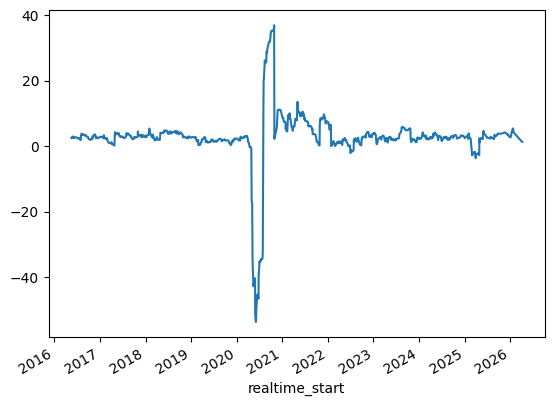

In [4]:
df_nowcast_raw = fred.get_series_all_releases('GDPNOW')
df_nowcast_raw ['realtime_start'] = pd.to_datetime(df_nowcast_raw['realtime_start'])
df_nowcast_raw ['date'] = pd.to_datetime(df_nowcast_raw['date'])

# Adattisztítás
df_now_sorted = df_nowcast_raw.sort_values(['realtime_start', 'date'])
df_nowcast_clean = df_now_sorted.groupby('realtime_start').last().reset_index()
df_nowcast_clean = df_nowcast_clean.set_index('realtime_start').sort_index()

display(df_nowcast_clean)

plt.figure()
df_nowcast_clean['value'].plot()
plt.show()

Adatbázis egyesítése

/tmp/ipykernel_13831/2528890609.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  combined_df = combined_df.ffill()


,gdp_official_point_in_time,date,value
2014-09-26,4.6,NaT,NaN
2014-09-27,4.6,NaT,NaN
2014-09-28,4.6,NaT,NaN
2014-09-29,4.6,NaT,NaN
2014-09-30,4.6,NaT,NaN
...,...,...,...
2026-04-05,0.7,2025-10-01,4.2373
2026-04-06,0.7,2025-10-01,4.2373
2026-04-07,0.7,2026-01-01,1.3205
2026-04-08,0.7,2026-01-01,1.3205


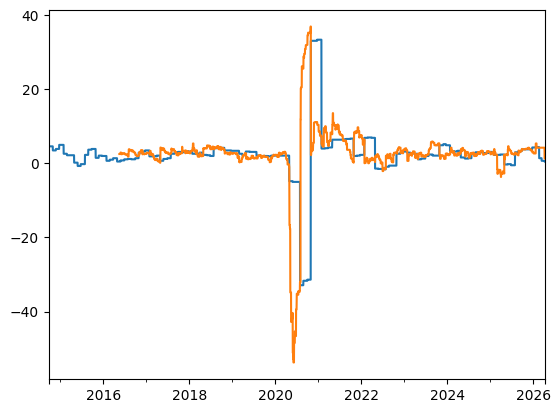

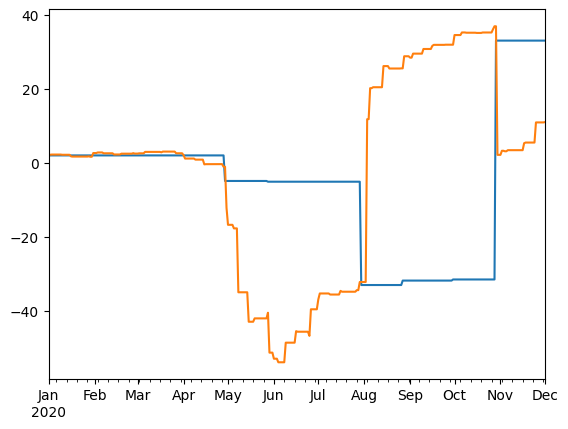

In [5]:
combined_df = df_final_signal.join(df_nowcast_clean, how='outer')
combined_df = combined_df.ffill()
display(combined_df)

plt.figure()
combined_df['gdp_official_point_in_time'].plot()
combined_df['value'].plot()
plt.show()

df_zoom = combined_df.loc['2020-01-01':'2020-12-01']
plt.figure()
df_zoom['gdp_official_point_in_time'].plot()
df_zoom['value'].plot()
plt.show()


# Variancia

In [6]:
def calculate_gdp_uncertainty_with_first_releases(df_combined, first_releases, window_years, days):
    # Szűrés munkanapokra és előkészítés
    df_res = df_combined.asfreq('B').dropna(subset=['value']).copy()
    first_releases = first_releases.copy()
    first_releases['realtime_start'] = pd.to_datetime(first_releases['realtime_start'])
    first_releases['date'] = pd.to_datetime(first_releases['date'])

    # Következő release keresése minden naphoz
    # Megnézzük, hogy a mához képest melyik az a legkorábbi 'realtime_start'
    def get_next_release_info(current_date):
        future_releases = first_releases[first_releases['realtime_start'] > current_date]
        if not future_releases.empty:
            next_r = future_releases.iloc[0]
            # Munkanapok száma a bejelentésig
            bd_left = np.busday_count(current_date.date(), next_r['realtime_start'].date())
            return next_r['realtime_start'], next_r['value'], bd_left
        return np.nan, np.nan, np.nan

    # Alkalmazzuk a keresést
    res_data = df_res.index.map(get_next_release_info)
    df_res['next_release_date'] = [x[0] for x in res_data]
    df_res['target_actual_value'] = [x[1] for x in res_data]
    df_res['days_left'] = [x[2] for x in res_data]

    df_res['is_release_day'] = df_res.index.isin(first_releases['realtime_start'])

    # Napi RMSE számítása
    df_res['SQ_Error_GDP'] = (df_res['value'] - df_res['target_actual_value'])**2

    # Dinamikus RMSE gördülő ablakkal
    def get_gdp_rmse(row, full_df):
        mask = (full_df.index < row.name) & \
               (full_df['is_release_day'] == True) & \
               (full_df.index >= row.name - pd.DateOffset(years=window_years)) & \
               (full_df['days_left'].between(row['days_left'] - days, row['days_left'] + days))

        sq_errors = full_df.loc[mask, 'SQ_Error_GDP']
        return np.sqrt(sq_errors.mean()) if not sq_errors.empty else np.nan

    # RMSE kiszámítása minden napra
    df_res['GDP_RMSE'] = df_res.apply(get_gdp_rmse, axis=1, args=(df_res,))

    # Variancia számítása
    df_res['GDP_RMSE'] = df_res['GDP_RMSE'].ffill().bfill()
    df_res['GDP_Var'] = df_res['GDP_RMSE']**2

    return df_res

combined_df_final = calculate_gdp_uncertainty_with_first_releases(combined_df, first_releases,3,5)

display(combined_df_final)

,gdp_official_point_in_time,date,value,next_release_date,target_actual_value,days_left,is_release_day,SQ_Error_GDP,GDP_RMSE,GDP_Var
2016-05-17,0.5,2016-04-01,2.5338,2016-07-29,1.2,53.0,False,1.779022,1.0667,1.137849
2016-05-18,0.5,2016-04-01,2.5338,2016-07-29,1.2,52.0,False,1.779022,1.0667,1.137849
2016-05-19,0.5,2016-04-01,2.5338,2016-07-29,1.2,51.0,False,1.779022,1.0667,1.137849
2016-05-20,0.5,2016-04-01,2.5338,2016-07-29,1.2,50.0,False,1.779022,1.0667,1.137849
2016-05-23,0.5,2016-04-01,2.5338,2016-07-29,1.2,49.0,False,1.779022,1.0667,1.137849
...,...,...,...,...,...,...,...,...,...,...
2026-04-03,0.7,2025-10-01,4.2373,NaT,NaN,NaN,False,NaN,2.0728,4.296500
2026-04-06,0.7,2025-10-01,4.2373,NaT,NaN,NaN,False,NaN,2.0728,4.296500
2026-04-07,0.7,2026-01-01,1.3205,NaT,NaN,NaN,False,NaN,2.0728,4.296500
2026-04-08,0.7,2026-01-01,1.3205,NaT,NaN,NaN,False,NaN,2.0728,4.296500


Hátralevő napok száma (days_left) robosztus-e?

Horizontok eloszlása az adatsorban:


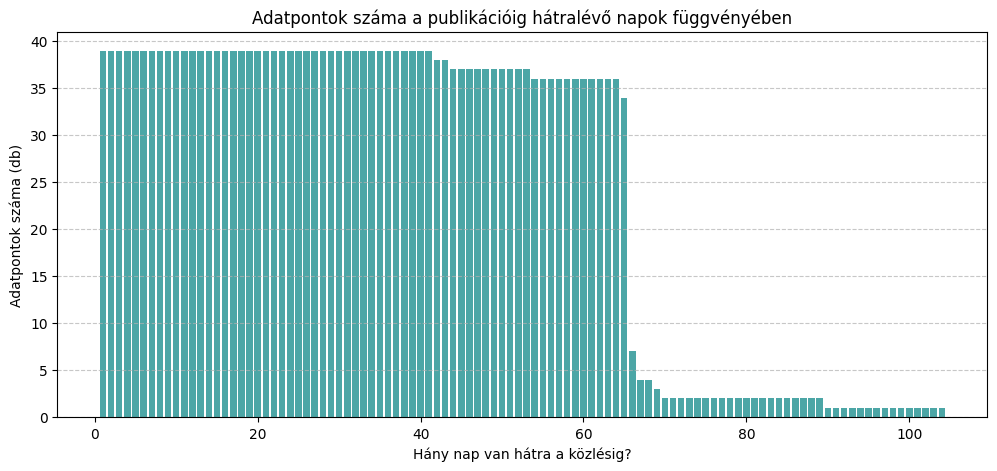

In [7]:
# Hány nap van hátra (az első) közlésig?
horizon_counts = combined_df_final['days_left'].value_counts().sort_index()
df_counts = horizon_counts.reset_index()
df_counts.columns = ['Napok a közlésig', 'Gyakoriság (db)']


print("Horizontok eloszlása az adatsorban:")
plt.figure(figsize=(12, 5))
plt.bar(df_counts['Napok a közlésig'], df_counts['Gyakoriság (db)'], color='teal', alpha=0.7)
plt.title('Adatpontok száma a publikációig hátralévő napok függvényében')
plt.xlabel('Hány nap van hátra a közlésig?')
plt.ylabel('Adatpontok száma (db)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

RMSE és varianciaábra

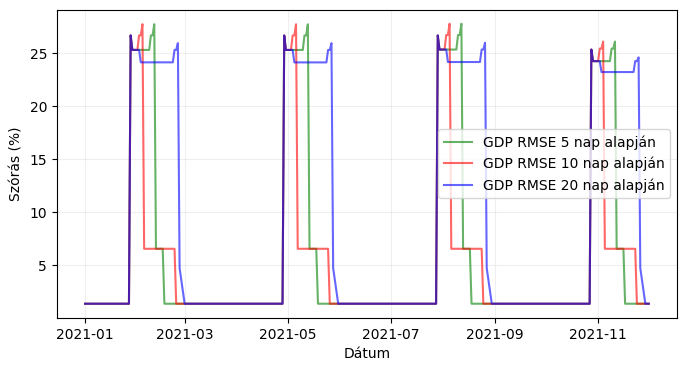

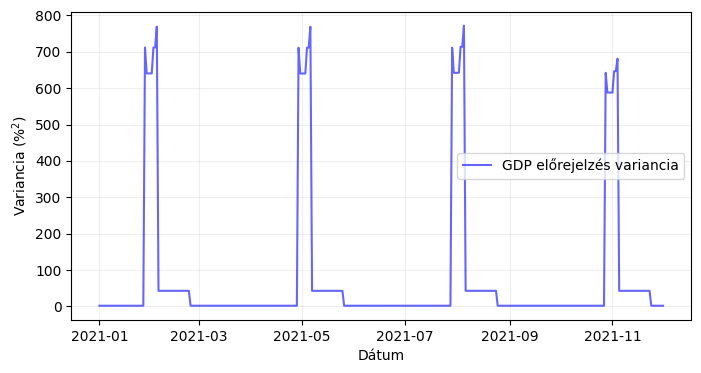

In [8]:
combined_df_final = calculate_gdp_uncertainty_with_first_releases(combined_df, first_releases,3,5) #végső választás: 3 év, +-5 nap
combined_df_final2 = calculate_gdp_uncertainty_with_first_releases(combined_df, first_releases,3,10)
combined_df_final3 = calculate_gdp_uncertainty_with_first_releases(combined_df, first_releases,3,20)

df_zoom = combined_df_final.loc['2021-01-01':'2021-12-01']
df_zoom2 = combined_df_final2.loc['2021-01-01':'2021-12-01']
df_zoom3 = combined_df_final3.loc['2021-01-01':'2021-12-01']

# RMSE vizsgált intervallum mérete alapján
plt.figure(figsize=(8, 4))
plt.plot(df_zoom2['GDP_RMSE'], label='GDP RMSE 5 nap alapján', color='green', alpha=0.6)
plt.plot(df_zoom['GDP_RMSE'], label='GDP RMSE 10 nap alapján', color='red', alpha=0.6)
plt.plot(df_zoom3['GDP_RMSE'], label='GDP RMSE 20 nap alapján', color='blue', alpha=0.6)
plt.grid(True, alpha=0.2)
plt.legend()
plt.xlabel('Dátum')
plt.ylabel('Szórás (%)')
plt.savefig('FRED_GDP_RMSE.pdf', bbox_inches='tight')
plt.show()

# GDP elérejelzés hiba variancia +-2 napos intervallum mellett
plt.figure(figsize=(8, 4))
plt.plot(df_zoom['GDP_Var'], label='GDP előrejelzés variancia', color='blue', alpha=0.6)
plt.grid(True, alpha=0.2)
plt.legend()
plt.xlabel('Dátum')
plt.ylabel(r'Variancia (%$^2$)')
plt.savefig('FRED_GDP_Var.pdf', bbox_inches='tight')
plt.show()

# Adatbázis mentése

In [9]:
combined_df_final = combined_df_final.rename(columns = {'gdp_official_point_in_time': 'GDP - Actual','value': 'GDP - Expectation'})

df_GDP_data = combined_df_final[['GDP - Actual','GDP - Expectation','GDP_Var']]
df_GDP_data.index.name = 'Date'
display(df_GDP_data)

df_GDP_data.to_csv('df_GDP_data.csv', index=True)

,GDP - Actual,GDP - Expectation,GDP_Var
Date,,,
2016-05-17,0.5,2.5338,1.137849
2016-05-18,0.5,2.5338,1.137849
2016-05-19,0.5,2.5338,1.137849
2016-05-20,0.5,2.5338,1.137849
2016-05-23,0.5,2.5338,1.137849
...,...,...,...
2026-04-03,0.7,4.2373,4.296500
2026-04-06,0.7,4.2373,4.296500
2026-04-07,0.7,1.3205,4.296500
